<a href="https://colab.research.google.com/github/akhunzakp/PCVK-2025/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# D1. Praktikum Deteksi Obyek Dasar

import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


2. Implementasikan 6 metode template matching pada OpenCV dengan
menggunakan gambar cats_and_bunnies.jpg dan cat2_templatejpg.jpg sebagai
templatenya.

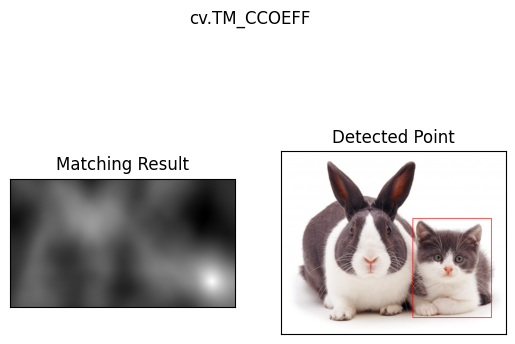

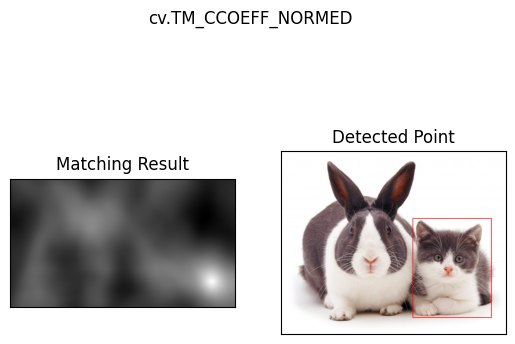

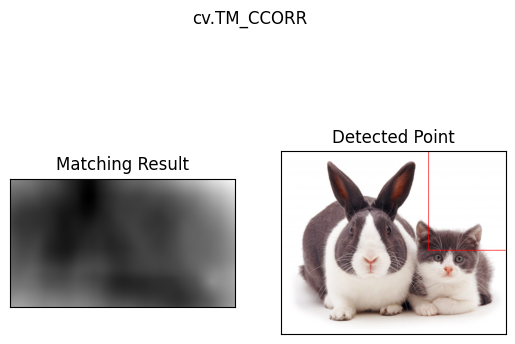

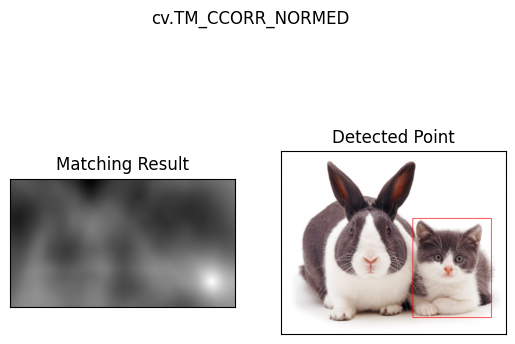

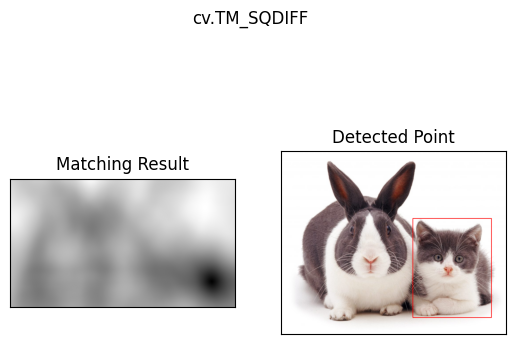

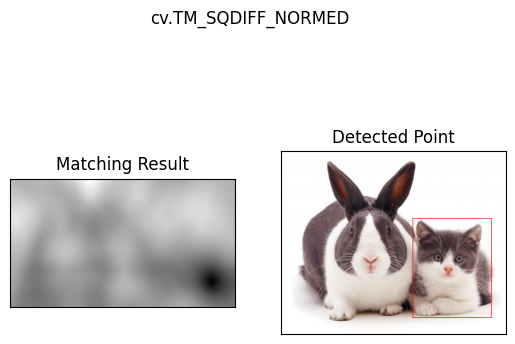

In [3]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/cats_and_bunnies.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
template = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/cat2_templatejpg.jpg', 0)
w, h = template.shape[::-1]

methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
           'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']

for meth_name in methods:
    img_color_copy = img_color.copy()
    method = eval(meth_name)

    res = cv.matchTemplate(img_gray, template, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)

    cv.rectangle(img_color_copy, top_left, bottom_right, (0, 0, 255), 2)

    img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img_rgb)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth_name)
    plt.show()

3. Implementasikan konsep template matching tanpa menggunakan library OpenCV
untuk multiple object, menggunakan gambar bahrain.jpg untuk citra masukan dan
bahrain-template.jpg sebagai citra template, sehingga menghasilkan output
sebagai berikut:

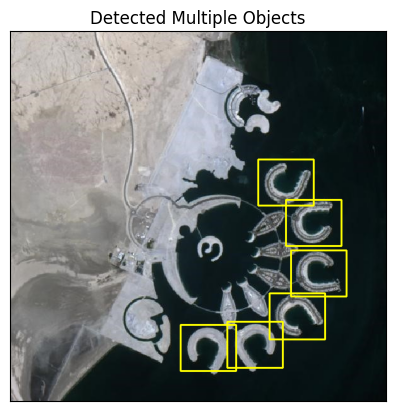

In [4]:
img_rgb = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/bahrain.jpg')
img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
template = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/bahrain-template.jpg', 0)
w, h = template.shape[::-1]

res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)

threshold = 0.45
loc = np.where(res >= threshold)

rectangles = []
for pt in zip(*loc[::-1]):
    rect = [int(pt[0]), int(pt[1]), int(w), int(h)]
    rectangles.append(rect)

boxes, weights = cv.groupRectangles(rectangles, 1, 0.2)

img_bgr_with_boxes = img_rgb.copy()
for (x, y, w, h) in boxes:
    cv.rectangle(img_bgr_with_boxes, (x, y), (x + w, y + h), (0, 255, 255), 2)

img_rgb_with_boxes = cv.cvtColor(img_bgr_with_boxes, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb_with_boxes)
plt.title('Detected Multiple Objects')
plt.xticks([]), plt.yticks([])
plt.show()

4. Implementasikan metode Sobel Edge Detection, Canny Edge
Detection, dan Laplacian Edge Detection pada OpenCV dengan
menggunakan gambar car-park.jpg, sehingga menghasilkan luaran
sebagai berikut:

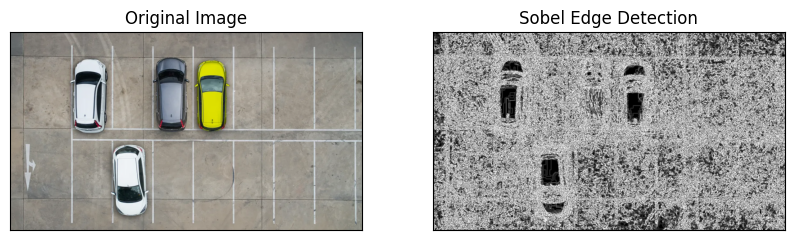

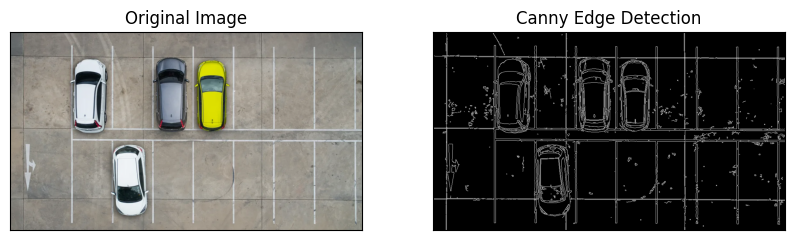

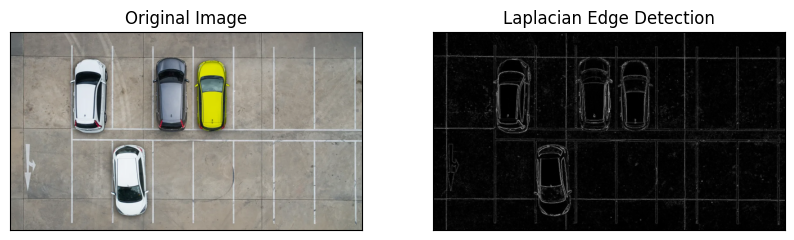

In [5]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/car-park.jpg')
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# a. Sobel Edge Detection

sobelx = cv.Sobel(img_gray, cv.CV_64F, 1, 0, ksize=5)
sobely = cv.Sobel(img_gray, cv.CV_64F, 0, 1, ksize=5)
sobel_combined = cv.bitwise_or(np.uint8(np.absolute(sobelx)),
                             np.uint8(np.absolute(sobely)))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

# b. Canny Edge Detection

canny_edges = cv.Canny(img_gray, 50, 150)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

# c. Laplacian Edge Detection

laplacian = cv.Laplacian(img_gray, cv.CV_64F)
laplacian_abs = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

5. Implementasikan metode Harris Corner Detection dan Shi-Tomasi
Detection pada OpenCV dengan menggunakan gambar chess-
board.jpg, sehingga menghasilkan luaran sebagai berikut:

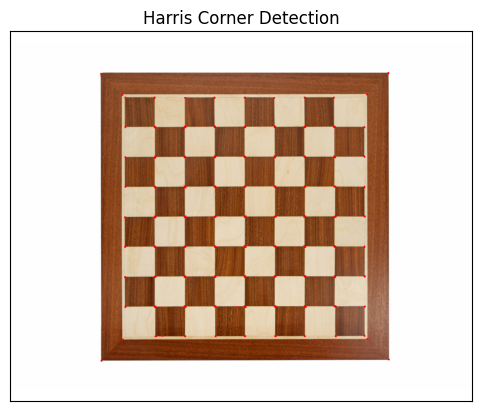

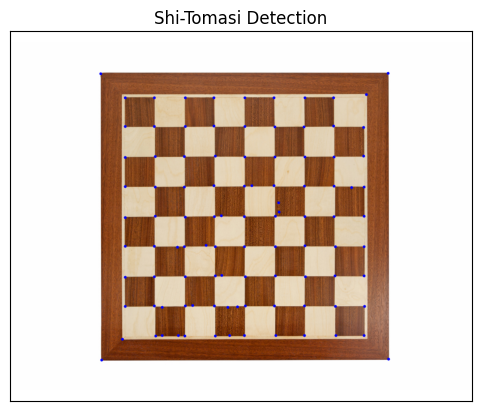

In [6]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/chess-board.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# a. Harris Corner Detection

img_harris = img_rgb.copy()

gray_float = np.float32(img_gray)
dst = cv.cornerHarris(gray_float, 2, 3, 0.04)

dst = cv.dilate(dst, None)

img_harris[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(img_harris)
plt.title('Harris Corner Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# Shi-Tomasi Detection

img_shi_tomasi = img_rgb.copy()

corners = cv.goodFeaturesToTrack(img_gray, 100, 0.01, 10)
corners = np.intp(corners)

for i in corners:
    x, y = i.ravel()
    cv.circle(img_shi_tomasi, (x, y), 3, (0, 0, 255), -1)

plt.imshow(img_shi_tomasi)
plt.title('Shi-Tomasi Detection')
plt.xticks([]), plt.yticks([])
plt.show()

6. Implementasikan metode Hough Transform pada OpenCV dengan
menggunakan gambar sudoku.jpg. Tahapan proses grid detection sesuai yang
terdapat pada ulasan teori, sehingga menghasilkan luaran sebagai berikut:

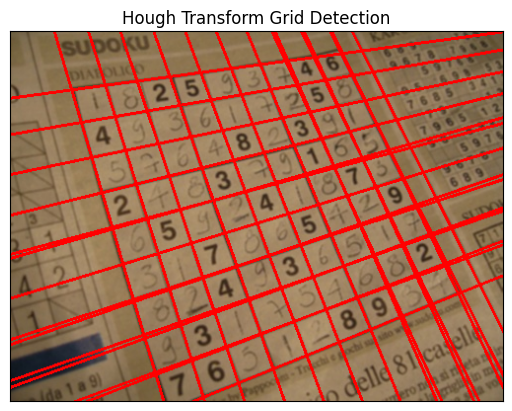

In [7]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/sudoku.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_color_copy = img.copy()

edges = cv.Canny(img_gray, 50, 150, apertureSize=3)

kernel = np.ones((3,3), np.uint8)
img_dilation = cv.dilate(edges, kernel, iterations=1)

img_erosion = cv.erode(img_dilation, kernel, iterations=1)

lines = cv.HoughLines(img_erosion, 1, np.pi / 175, 290)

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv.line(img_color_copy, (x1, y1), (x2, y2), (0, 0, 255), 2)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Hough Transform Grid Detection')
plt.xticks([]), plt.yticks([])
plt.show()

7. Implementasikan fungsi findContours() pada OpenCV untuk contour detection
dengan menggunakan gambar laptop.jpg, sehingga menghasilkan luaran
sebagai berikut:

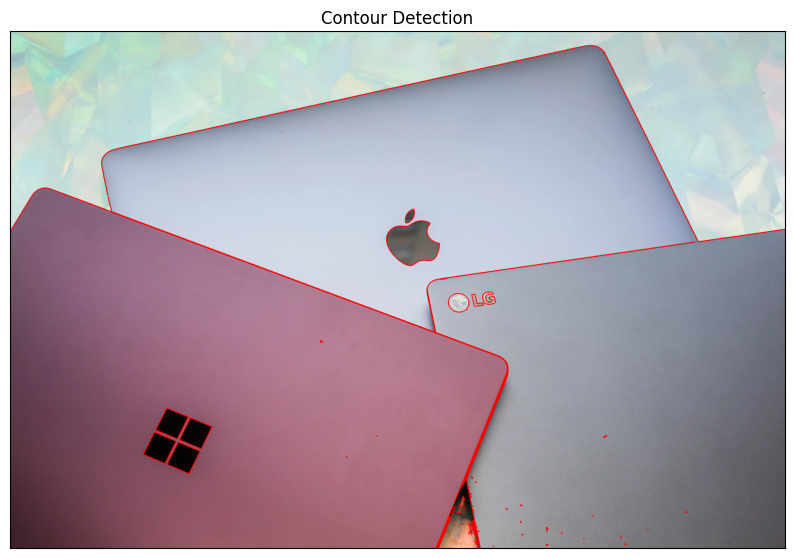

In [8]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/laptop.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

edges = cv.Canny(img_gray, 50, 150)

contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

img_color_copy = img_color.copy()

cv.drawContours(img_color_copy, contours, -1, (0, 0, 255), 3)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(img_rgb)
plt.title('Contour Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# **D2. Praktikum Feature Matching dan Face Detection**

1. Lakukan Face Detection untuk image object lain yang tersedia pada
(/images/facedet). Tampilkan seperti pada contoh berikut.

Jumlah file ditemukan: 6
File: ['/content/drive/MyDrive/PCVK/Images/facedet/many_cereals.jpg', '/content/drive/MyDrive/PCVK/Images/facedet/mjordan.jpg', '/content/drive/MyDrive/PCVK/Images/facedet/kartini.jpg', '/content/drive/MyDrive/PCVK/Images/facedet/kucing.jpg', '/content/drive/MyDrive/PCVK/Images/facedet/solvayconf.jpg', '/content/drive/MyDrive/PCVK/Images/facedet/jokowi.jpg']


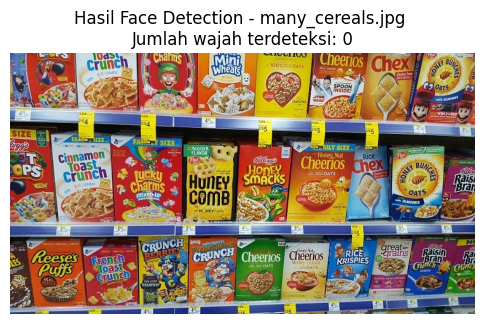

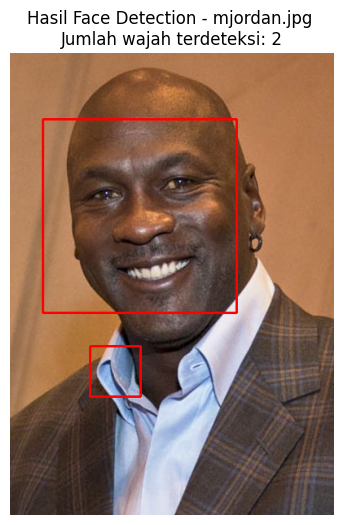

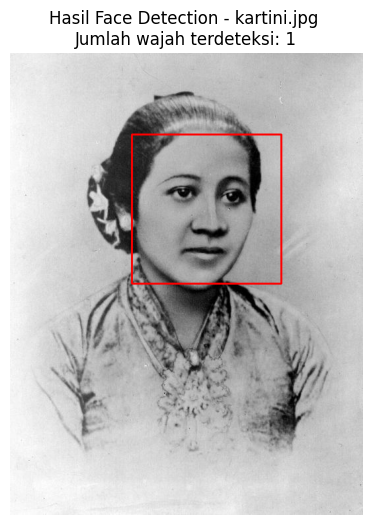

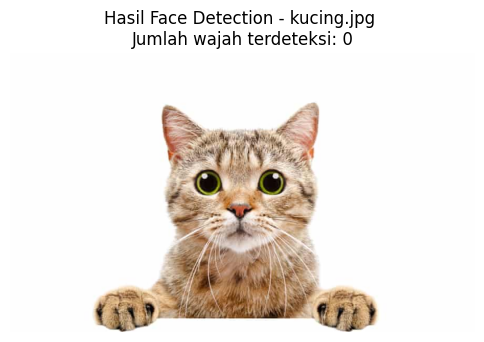

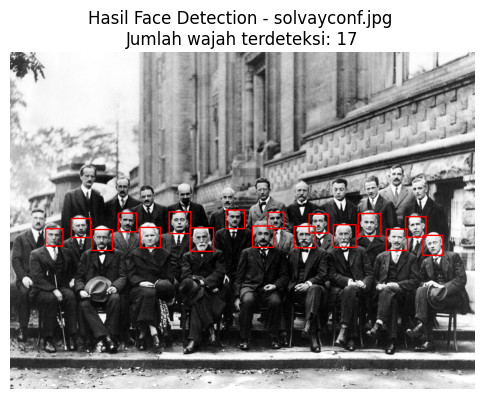

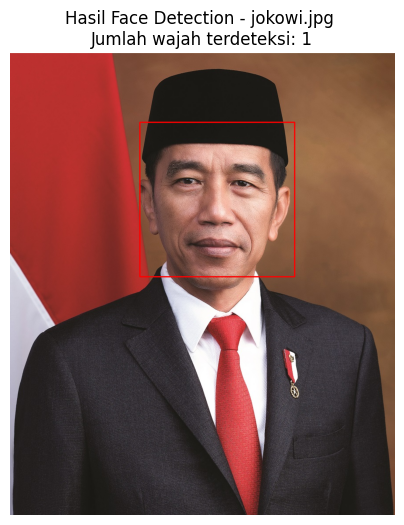

In [10]:
import cv2
import matplotlib.pyplot as plt
import glob

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

image_paths = glob.glob('/content/drive/MyDrive/PCVK/Images/facedet/*.jpg')  # ganti sesuai lokasi kamu

print("Jumlah file ditemukan:", len(image_paths))
print("File:", image_paths)

for path in image_paths:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Deteksi wajah
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=9,
        minSize=(30, 30)
    )

    # Gambar kotak merah di setiap wajah
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)

    # Tampilkan hasil
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Hasil Face Detection - {path.split("/")[-1]} \nJumlah wajah terdeteksi: {len(faces)}')
    plt.axis('off')
    plt.show()


2. Pada Soal No.2. wajah kucing tidak bisa dideteksi dengan baik. Lakukan deteksi
wajah kucing hingga muncul rectangle pada bagian wajahnya. Petunjuk pada soal
ini, perhatikan pretrained features yang telah disediakan OpenCV. Gunakan xml
yang ada jika memang telah disediakan. Jika belum ada, coba cari dengan
searching melalui search engines.

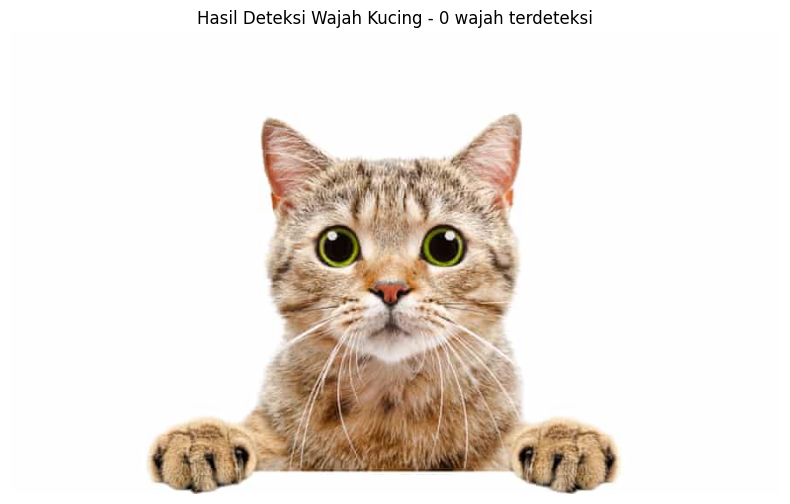

In [11]:
import cv2
import matplotlib.pyplot as plt

cat_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface_extended.xml')

img = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/kucing.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

h, w = gray.shape
gray_crop = gray[:int(h*0.65), :]

gray_crop = cv2.GaussianBlur(gray_crop, (5,5), 0)

cats = cat_cascade.detectMultiScale(
    gray_crop,
    scaleFactor=1.01,
    minNeighbors=5,
    minSize=(90, 90)
)

output = img.copy()
for (x, y, w, h) in cats:
    cv2.rectangle(output, (x, y), (x+w, y+h), (0, 0, 255), 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Hasil Deteksi Wajah Kucing - {len(cats)} wajah terdeteksi')
plt.axis('off')
plt.show()


3. Cobakan juga untuk eyes detection pada wajah Pak Prabowo:

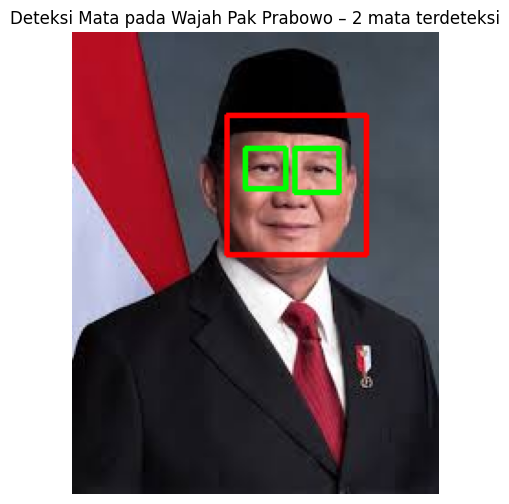

In [12]:
import cv2
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

img = cv2.imread('/content/drive/MyDrive/PCVK/Images/prabowo.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.convertScaleAbs(gray, alpha=1.2, beta=5)   # alpha > 1.0 = kontras ↑

faces = face_cascade.detectMultiScale(gray, 1.1, 5)
output = img.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(output, (x, y), (x+w, y+h), (0, 0, 255), 2)

    roi_gray = gray[y:y+int(h*0.8), x:x+w]      # dulu y:y+h → sekarang 80 % tinggi wajah
    roi_color = output[y:y+int(h*0.8), x:x+w]

    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.01,
        minNeighbors=2,       # sedikit lebih longgar
        minSize=(10, 10),
        maxSize=(55, 55)      # sedikit lebih lebar area
    )

    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Deteksi Mata pada Wajah Pak Prabowo – {len(eyes)} mata terdeteksi')
plt.axis('off')
plt.show()


4. Lakukan deteksi senyuman pada gambar people:

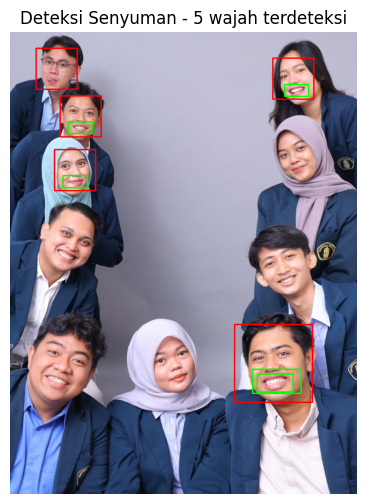

In [3]:
import cv2
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

img = cv2.imread('/content/drive/MyDrive/PCVK/Bestfriend Photobox.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.9,
    minNeighbors=3,
    minSize=(80, 80)
)

output = img.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 0, 255), 2)

    roi_gray = gray[y:y + h, x:x + w]
    roi_color = output[y:y + h, x:x + w]

    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.3,
        minNeighbors=7,
        minSize=(20, 20)
    )

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Deteksi Senyuman - {len(faces)} wajah terdeteksi')
plt.axis('off')
plt.show()


5. Lakukan Face Tracking menggunakan Google Colab. Petunjuk, Tutorial
selengkapnya tentang akses kamera dan FaceDetection pada google colab dapat
dilihat di link berikut: https://www.youtube.com/watch?v=YjWh7QvVH60

In [11]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

In [12]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

In [13]:
# initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))

In [14]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename

<IPython.core.display.Javascript object>

(480, 640)
Saved to photo.jpg


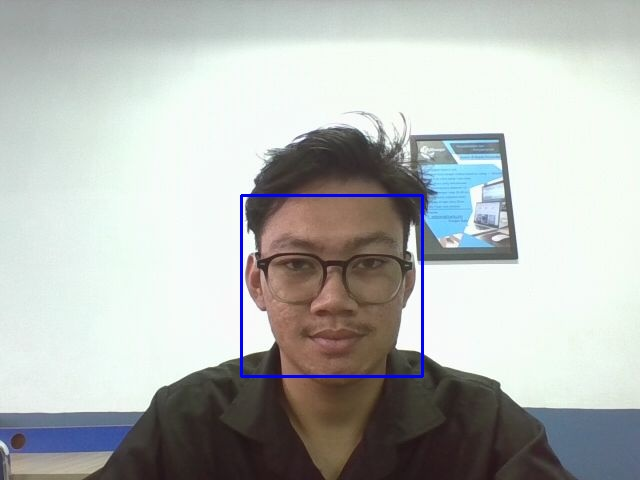

In [16]:
try:
  filename = take_photo('photo.jpg')
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

In [17]:
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

In [19]:
# start streaming video from webcam
video_stream()
# label for video
label_html = 'Capturing...'
# initialze bounding box to empty
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # convert JS response to OpenCV Image
    img = js_to_image(js_reply["img"])

    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # grayscale image for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # get face region coordinates
    faces = face_cascade.detectMultiScale(gray)
    # get face bounding box for overlay
    for (x,y,w,h) in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes

<IPython.core.display.Javascript object>

/tmp/ipython-input-480462610.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


6. Lakukan Blurring pada bagian wajah yang terdeteksi. Berikut contoh keluarannya.
Petunjuk: anda dapat menggunakan cv.medianBlur untuk melakukan Blurring

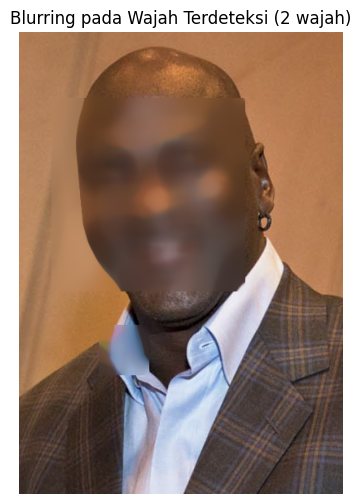

In [20]:
import cv2
import matplotlib.pyplot as plt

# 1️⃣ Load pretrained face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2️⃣ Baca gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/mjordan.jpg')  # ganti sesuai file kamu
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3️⃣ Deteksi wajah
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# 4️⃣ Lakukan blurring di area wajah
output = img.copy()
for (x, y, w, h) in faces:
    face_region = output[y:y+h, x:x+w]
    # Gunakan median blur
    blurred_face = cv2.medianBlur(face_region, 35)   # semakin besar kernel → semakin blur
    output[y:y+h, x:x+w] = blurred_face

# 5️⃣ Tampilkan hasil
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Blurring pada Wajah Terdeteksi ({len(faces)} wajah)')
plt.axis('off')
plt.show()


7. Mengolah gambar KTM masing-masing

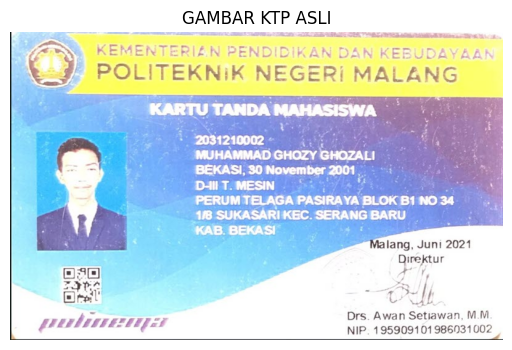

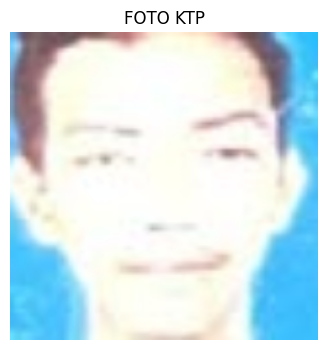

In [22]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.imshow(img_rgb)
plt.title("GAMBAR KTP ASLI")
plt.axis('off')
plt.show()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

if len(faces) > 0:
    for (x, y, w, h) in faces:
        roi = img[y:y+h, x:x+w]
        foto_ktm = cv2.resize(roi, (250, 250))
else:
    foto_ktm = img[130:380, 40:280]
    foto_ktm = cv2.resize(foto_ktm, (250, 250))

foto_ktm_rgb = cv2.cvtColor(foto_ktm, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(foto_ktm_rgb)
plt.title("FOTO KTP")
plt.axis('off')
plt.show()